# Bài tập nhóm — Khám phá & Chinh phục môi trường Gym
## Môi trường: **CartPole-v1** và **Acrobot-v1**

**Nhóm:** _(điền tên thành viên)_
**Thư viện:** `gymnasium 1.3.0` (bản kế nhiệm chính thức của `gym`)

| Phần | Nội dung |
|---|---|
| A | Giới thiệu môi trường: mục tiêu, không gian quan sát/hành động, hàm thưởng, điều kiện kết thúc |
| B | Thay đổi tham số vật lý và đo ảnh hưởng tới độ khó |
| C | Chơi tay, Random agent (100 tập), heuristic đơn giản |
| D | Bảng/biểu đồ kết quả, phân tích, chiến lược thắng |

> **Lưu ý về phiên bản.** Đề bài viết theo API `gym` cũ. Ở `gymnasium`, `env.step()` trả về **5** giá trị
> `(obs, reward, terminated, truncated, info)` thay vì 4, và `env.reset()` trả về `(obs, info)`.
> Toàn bộ notebook này dùng API mới.

In [2]:
%pip install gymnasium

  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached farama_notifications-0.0.6-py3-none-any.whl.metadata (729 bytes)
Using cached gymnasium-1.3.0-py3-none-any.whl (953 kB)
Using cached farama_notifications-0.0.6-py3-none-any.whl (2.9 kB)

   -------------------- ------------------- 1/2 [gymnasium]
   ---------------------------------------- 2/2 [gymnasium]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# !pip install gymnasium matplotlib pandas
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import gymnasium as gym

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})
print("gymnasium", gym.__version__)

gymnasium 1.3.0


---
# PHẦN A — Giới thiệu môi trường

## A.1 CartPole-v1

**Mục tiêu.** Một cây cột (pole) được gắn bằng khớp *không có động cơ* lên một chiếc xe (cart) trượt trên
đường ray không ma sát. Cột bắt đầu ở tư thế gần thẳng đứng và sẽ đổ. Người chơi chỉ được đẩy xe sang
trái hoặc phải để **giữ cột đứng càng lâu càng tốt**. Đây là bài toán điều khiển ngược (inverted pendulum)
kinh điển.

In [23]:
env = gym.make("CartPole-v1")
print("Observation space:", env.observation_space)
print("\nLow:", env.observation_space.low)
print("\nHigh:", env.observation_space.high)
print("\nAction space:", env.action_space)
obs, info = env.reset(seed=0)
print("Observation đầu tiên:", obs)

env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Low: [-4.8               -inf -0.41887903        -inf]

High: [4.8               inf 0.41887903        inf]

Action space: Discrete(2)
Observation đầu tiên: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]


### Không gian quan sát — `Box(4,)`, số thực

| # | Biến | Ý nghĩa | Khoảng giá trị | Ngưỡng kết thúc |
|---|---|---|---|---|
| 0 | `x` | vị trí xe | [-4.8, 4.8] | \|x\| > **2.4** |
| 1 | `x_dot` | vận tốc xe | (-∞, ∞) | — |
| 2 | `theta` | góc nghiêng cột (radian) | ≈[-0.418, 0.418] | \|θ\| > **0.2095** (≈12°) |
| 3 | `theta_dot` | vận tốc góc của cột | (-∞, ∞) | — |

Chú ý: khoảng của observation space **rộng hơn** ngưỡng kết thúc. Ví dụ `x` được khai báo tới ±4.8
nhưng tập chơi đã dừng ở ±2.4 — đây là chi tiết dễ hiểu nhầm.

### Không gian hành động — `Discrete(2)`

| Hành động | Ý nghĩa |
|---|---|
| `0` | đẩy xe sang **trái** với lực `force_mag` |
| `1` | đẩy xe sang **phải** với lực `force_mag` |

Lực luôn có **độ lớn cố định**; ta chỉ chọn được *chiều*, không chọn được *độ mạnh*. Gia tốc thực tế
của cột còn phụ thuộc góc nghiêng hiện tại, nên cùng một hành động có hiệu ứng khác nhau tuỳ trạng thái.

### Hàm thưởng & điều kiện kết thúc

- **Reward:** `+1` cho **mỗi bước**, kể cả bước cuối cùng làm cột đổ. Reward tối đa = 500.
- **`terminated = True`** khi: \|θ\| > 12°, hoặc \|x\| > 2.4 (xe chạy khỏi màn hình).
- **`truncated = True`** khi đạt 500 bước (giới hạn của `TimeLimit` wrapper trong `-v1`).
- Ngưỡng "giải được" truyền thống: reward trung bình ≥ **195** trên 100 tập liên tiếp.

Vì reward chỉ đếm số bước sống sót, **reward ≡ độ dài tập**. Đây là tín hiệu thưởng *dày* (dense) —
agent nhận phản hồi mỗi bước, nên bài toán tương đối dễ học.

## A.2 Acrobot-v1

**Mục tiêu.** Hệ hai thanh nối nhau (giống cánh tay có khuỷu) treo xuống. Khớp trên **cố định, không có
động cơ**; chỉ khớp giữa hai thanh là truyền được mô-men. Nhiệm vụ: **đung đưa đầu thanh dưới lên cao hơn
khớp treo một đoạn bằng chiều dài một thanh**. Vì mô-men quá yếu để nhấc thẳng lên, agent **bắt buộc phải
đung đưa qua lại để tích luỹ năng lượng** — đây là điểm cốt lõi của bài toán.

In [12]:
env = gym.make("Acrobot-v1")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
obs, info = env.reset(seed=0)
print("Observation đầu tiên:", obs)
u = env.unwrapped
print("Mô-men khả dụng:", u.AVAIL_TORQUE)
env.close()

Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Action space: Discrete(3)
Observation đầu tiên: [ 0.99962485  0.02738891  0.9989402  -0.04602639 -0.09180529 -0.09669447]
Mô-men khả dụng: [-1.0, 0.0, 1]


### Không gian quan sát — `Box(6,)`

| # | Biến | Khoảng |
|---|---|---|
| 0 | `cos(θ1)` | [-1, 1] |
| 1 | `sin(θ1)` | [-1, 1] |
| 2 | `cos(θ2)` | [-1, 1] |
| 3 | `sin(θ2)` | [-1, 1] |
| 4 | `θ1_dot` (vận tốc góc khớp 1) | [-4π, 4π] |
| 5 | `θ2_dot` (vận tốc góc khớp 2) | [-9π, 9π] |

Môi trường trả về **`cos` và `sin` của góc thay vì góc thô**. Lý do: góc là đại lượng tuần hoàn —
0 và 2π là cùng một tư thế nhưng cách nhau rất xa về mặt số học, khiến mạng nơ-ron học rất khó.
Cặp (cos, sin) là biểu diễn liên tục, không có điểm nhảy. `θ1` đo so với phương thẳng đứng hướng xuống
(θ1 = 0 nghĩa là thanh 1 chỉ thẳng xuống), `θ2` đo **tương đối** so với thanh 1.

### Không gian hành động — `Discrete(3)`

| Hành động | Mô-men lên khớp giữa |
|---|---|
| `0` | −1 N·m |
| `1` | 0 (thả trôi) |
| `2` | +1 N·m |

### Hàm thưởng & điều kiện kết thúc

- **Reward:** `−1` cho **mỗi bước chưa đạt mục tiêu**, `0` ở bước đạt mục tiêu.
  → Càng lâu càng bị phạt nặng, nên agent bị thúc ép về đích **nhanh nhất có thể**.
- **`terminated`** khi `−cos(θ1) − cos(θ2 + θ1) > 1.0` (đầu thanh dưới vượt ngưỡng chiều cao).
- **`truncated`** khi đạt 500 bước → reward tập = **−500** (trường hợp xấu nhất).
- Ngưỡng "giải được": reward trung bình > **−100**.

**Đối lập cơ bản với CartPole:** CartPole thưởng cho việc *kéo dài* tập, Acrobot phạt cho việc kéo dài.
CartPole có reward dày và hữu ích ngay từ đầu; Acrobot về bản chất là **thưởng thưa** — mọi bước đều
là −1 nên tín hiệu −1 *không phân biệt* hành động tốt/xấu. Agent chỉ nhận được thông tin hữu ích khi
tình cờ chạm đích lần đầu. Đây là lý do random agent gần như không bao giờ thắng Acrobot.

---
# Khung đánh giá dùng chung

Định nghĩa "thắng" cho mỗi môi trường:
- **CartPole:** sống sót ≥ 195 bước (chuẩn cổ điển).
- **Acrobot:** `terminated == True`, tức chạm mốc chiều cao trước khi hết 500 bước.

Mọi thí nghiệm dưới đây chạy **100 tập** (đề yêu cầu tối thiểu 50) với seed cố định `0..99`
để các cấu hình khác nhau được so sánh trên **cùng bộ trạng thái khởi đầu** — nếu không, chênh lệch
quan sát được có thể chỉ là nhiễu ngẫu nhiên.

In [24]:
N_EPISODES = 100

def is_success(env_id, terminated, steps):
    if env_id.startswith("CartPole"):
        return steps >= 195
    if env_id.startswith("Acrobot"):
        return bool(terminated)
    return bool(terminated)

def evaluate(env_id, policy, n_episodes=N_EPISODES, seed=0, param_setter=None):
    """Chạy n_episodes tập, trả về thống kê. param_setter chỉnh tham số vật lý qua env.unwrapped."""
    env = gym.make(env_id)
    if param_setter is not None:
        param_setter(env.unwrapped)
    rewards, lengths, wins = [], [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        env.action_space.seed(seed + ep)
        total, steps, term, trunc = 0.0, 0, False, False
        while not (term or trunc):
            obs, r, term, trunc, _ = env.step(policy(obs, env))
            total += r; steps += 1
        rewards.append(total); lengths.append(steps)
        wins.append(is_success(env_id, term, steps))
    env.close()
    rewards, lengths = np.array(rewards), np.array(lengths, dtype=float)
    return {"mean_reward": rewards.mean(), "std_reward": rewards.std(),
            "mean_steps": lengths.mean(), "success_rate": 100 * np.mean(wins),
            "rewards": rewards}

def row(label, s):
    return {"Cấu hình": label, "Reward TB": round(s["mean_reward"], 2),
            "Độ lệch chuẩn": round(s["std_reward"], 2),
            "Số bước TB": round(s["mean_steps"], 1),
            "Tỉ lệ thắng (%)": round(s["success_rate"], 1)}

def setter(**kw):
    def f(u):
        for k, v in kw.items(): setattr(u, k, v)
    return f

---
# PHẦN C.1 — Chơi tay (manual play)

Môi trường ở đây chạy không có màn hình (headless) nên ta "chơi tay" bằng cách **đưa vào một chuỗi hành
động do người chọn** và in ra trạng thái từng bước. Cách này thực ra *tốt hơn* để trình bày trước lớp,
vì ta nhìn thấy trực tiếp các con số trong observation thay đổi ra sao.

Thí nghiệm 1: **luôn đẩy sang phải** — quan sát cột đổ nhanh thế nào.

In [25]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)
print(f"{'bước':>5} {'x':>8} {'x_dot':>8} {'theta°':>8} {'theta_dot':>10}  hành động")
for t in range(1, 40):
    action = 1                      # <-- đổi số này để "chơi tay"
    obs, r, term, trunc, _ = env.step(action)
    if t % 3 == 0 or term:
        print(f"{t:>5} {obs[0]:>8.3f} {obs[1]:>8.3f} "
              f"{np.degrees(obs[2]):>8.2f} {obs[3]:>10.3f}  {'phải' if action else 'trái'}")
    if term or trunc:
        print(f"\n>>> Kết thúc sau {t} bước. Góc cuối = {np.degrees(obs[2]):.2f}° (ngưỡng ±12°)")
        break
env.close()

 bước        x    x_dot   theta°  theta_dot  hành động
    3    0.039    0.578     1.16     -0.825  phải
    6    0.085    1.163    -2.67     -1.701  phải
    9    0.167    1.750    -9.59     -2.652  phải
   10    0.202    1.946   -12.62     -2.991  phải

>>> Kết thúc sau 10 bước. Góc cuối = -12.62° (ngưỡng ±12°)


Thí nghiệm 2: **chơi tay bằng cách sửa lỗi thủ công** — ta nhìn góc và tự quyết định, mô phỏng đúng
việc một người bấm phím trái/phải. Chạy ô dưới rồi thử đổi danh sách `plan`.

In [ ]:
def play_manual(plan, seed=42, env_id="CartPole-v1"):
    """plan: danh sách hành động. Trả về tổng reward."""
    env = gym.make(env_id)
    obs, _ = env.reset(seed=seed)
    total = 0
    for t, a in enumerate(plan, 1):
        obs, r, term, trunc, _ = env.step(a)
        total += r
        if term or trunc:
            print(f"Kết thúc ở bước {t}, tổng reward = {total}")
            env.close(); return total
    print(f"Hết chuỗi hành động sau {len(plan)} bước, tổng reward = {total}, "
          f"góc hiện tại = {np.degrees(obs[2]):.2f}°")
    env.close(); return total

print("— Luôn đẩy phải:");       play_manual([1] * 100)
print("\n— Trái/phải xen kẽ:");   play_manual([0, 1] * 50)
print("\n— Hai phải một trái:");  play_manual([1, 1, 0] * 34)

**Nhận xét từ chơi tay.** Đẩy xen kẽ trái–phải sống lâu hơn hẳn đẩy một chiều, vì nó giữ cho vận tốc
xe dao động quanh 0. Nhưng kể cả xen kẽ cũng chết, vì nó **không nhìn vào trạng thái** — khi cột đã
nghiêng thì việc đẩy nhịp nhàng vô nghĩa. Đây chính là động lực để chuyển sang heuristic có phản hồi
ở Phần C.3.

Với **Acrobot**, chơi tay theo chuỗi cố định gần như chắc chắn thất bại — ta thử đẩy một chiều liên tục:

Luôn đẩy một chiều: 500 bước, reward = -500.0, đạt đích = False
Chiều cao lớn nhất đạt được = -1.879 (cần > 1.0)


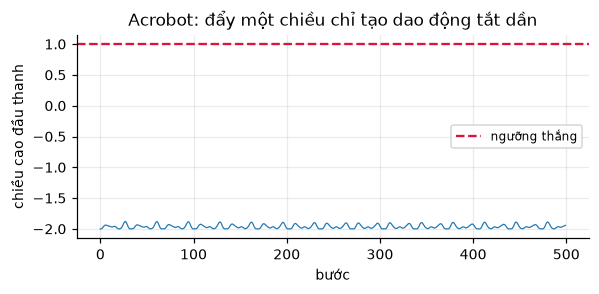

In [26]:
env = gym.make("Acrobot-v1")
obs, _ = env.reset(seed=0)
total = 0
heights = []
for t in range(500):
    obs, r, term, trunc, _ = env.step(2)   # luôn +1 N·m
    total += r
    h = -obs[0] - (obs[0] * obs[2] - obs[1] * obs[3])   # -cos(t1) - cos(t1+t2)
    heights.append(h)
    if term: break
print(f"Luôn đẩy một chiều: {t+1} bước, reward = {total}, đạt đích = {term}")
print(f"Chiều cao lớn nhất đạt được = {max(heights):.3f} (cần > 1.0)")

plt.figure(figsize=(6, 2.4))
plt.plot(heights, lw=.8); plt.axhline(1.0, color="crimson", ls="--", label="ngưỡng thắng")
plt.xlabel("bước"); plt.ylabel("chiều cao đầu thanh"); plt.legend(fontsize=8)
plt.title("Acrobot: đẩy một chiều chỉ tạo dao động tắt dần"); plt.show()

Đồ thị cho thấy vấn đề rất rõ: mô-men một chiều chỉ đưa hệ tới một **điểm cân bằng lệch** rồi dao động
quanh đó, không bao giờ tích đủ năng lượng. Muốn thắng, mô-men **phải đổi dấu đồng bộ với chuyển động** —
giống hệt việc đẩy xích đu.

---
# PHẦN C.2 & C.3 — Random agent và Heuristic

## Thiết kế các heuristic

**CartPole**
- **H1 — chỉ nhìn góc:** `nghiêng phải → đẩy phải`. Trực giác đúng nhưng thiếu thông tin.
- **H2 — bộ điều khiển PD:** `u = θ + 0.5·θ̇`. Thêm số hạng đạo hàm giúp *dự đoán trước* thay vì phản ứng muộn.
- **H3 — PD + giữ xe ở tâm:** `u = θ + 0.5·θ̇ + 0.02·x + 0.05·ẋ`, chống việc xe trôi dần ra khỏi ±2.4.

**Acrobot**
- **H1 — mô-men cố định:** luôn `+1`, dùng làm mốc so sánh.
- **H2 — bơm năng lượng:** đẩy mô-men **cùng dấu với `θ̇2`**. Công = mô-men × vận tốc góc, nên cùng dấu
  nghĩa là **luôn bơm năng lượng vào hệ** ở mọi bước. Đây là luật xích đu viết bằng một dòng.

In [27]:
def random_agent(obs, env): return env.action_space.sample()

# --- CartPole ---
def cartpole_naive(obs, env):
    return 1 if obs[2] > 0 else 0

def cartpole_pd(obs, env):
    return 1 if obs[2] + 0.5 * obs[3] > 0 else 0

def cartpole_pd_full(obs, env):
    x, x_dot, th, th_dot = obs
    return 1 if th + 0.5 * th_dot + 0.02 * x + 0.05 * x_dot > 0 else 0

# --- Acrobot ---
def acrobot_naive(obs, env): return 2

def acrobot_pump(obs, env):
    return 2 if obs[5] > 0 else 0      # obs[5] = theta2_dot

In [28]:
cp_agents = [("Random", random_agent),
             ("H1: chỉ nhìn góc", cartpole_naive),
             ("H2: PD (góc + vận tốc góc)", cartpole_pd),
             ("H3: PD + giữ xe ở tâm", cartpole_pd_full)]

cp_stats = {n: evaluate("CartPole-v1", p) for n, p in cp_agents}
df_cp = pd.DataFrame([row(n, s) for n, s in cp_stats.items()])
print("CartPole-v1 — 100 tập / agent"); display(df_cp)

CartPole-v1 — 100 tập / agent


,Cấu hình,Reward TB,Độ lệch chuẩn,Số bước TB,Tỉ lệ thắng (%)
0,Random,24.96,15.38,25.0,0.0
1,H1: chỉ nhìn góc,41.04,8.62,41.0,0.0
2,H2: PD (góc + vận tốc góc),500.00,0.00,500.0,100.0
3,H3: PD + giữ xe ở tâm,500.00,0.00,500.0,100.0


In [ ]:
ac_agents = [("Random", random_agent),
             ("H1: mô-men cố định", acrobot_naive),
             ("H2: bơm năng lượng", acrobot_pump)]

ac_stats = {n: evaluate("Acrobot-v1", p) for n, p in ac_agents}
df_ac = pd.DataFrame([row(n, s) for n, s in ac_stats.items()])
print("Acrobot-v1 — 100 tập / agent"); display(df_ac)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist([cp_stats["Random"]["rewards"], cp_stats["H1: chỉ nhìn góc"]["rewards"]],
           bins=20, label=["Random", "H1"], color=["#9aa0a6", "#7a9e9f"])
ax[0].axvline(500, color="#c1614a", lw=2, label="H2/H3 (luôn 500)")
ax[0].axvline(195, color="k", ls="--", lw=1, label="ngưỡng thắng")
ax[0].set_title("CartPole: phân phối reward"); ax[0].legend(fontsize=7)

ax[1].hist([ac_stats["Random"]["rewards"], ac_stats["H2: bơm năng lượng"]["rewards"]],
           bins=20, label=["Random", "H2 bơm năng lượng"], color=["#9aa0a6", "#c1614a"])
ax[1].axvline(-100, color="k", ls="--", lw=1, label="ngưỡng giải được")
ax[1].set_title("Acrobot: phân phối reward"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

### Nhận xét

**CartPole.** Random đạt ~25 điểm — cột đổ sau chưa tới nửa giây mô phỏng. H1 (chỉ nhìn góc) tăng lên ~41,
tức **cải thiện 64% nhưng vẫn thất bại 100%**. Nguyên nhân: khi ta thấy góc dương và đẩy sang phải, cột đã
đang *xoay* theo chiều đó rồi — phản ứng luôn chậm một nhịp, biên độ dao động lớn dần tới khi vượt 12°.
Chỉ cần **thêm một số hạng vận tốc góc** (H2) là điểm nhảy từ 41 lên **500 tuyệt đối, 100% thắng**.
Bài học: thông tin đạo hàm quan trọng hơn việc tinh chỉnh hệ số.

**Acrobot.** Random đạt **đúng −500 ở cả 100 tập** — không một lần nào thắng. Mô-men cố định (H1) cũng vậy.
Heuristic bơm năng lượng đạt **−84.4, thắng 100%**, vượt xa ngưỡng "giải được" là −100. Một dòng lệnh
`return 2 if obs[5] > 0 else 0` đủ để giải quyết môi trường mà random không bao giờ chạm tới.

---
# PHẦN B — Thay đổi tham số & đo độ khó

Tham số vật lý nằm trên **`env.unwrapped`**, không phải trên đối tượng `env` do `gym.make()` trả về —
`gym.make` bọc môi trường trong các wrapper (`TimeLimit`, `OrderEnforcing`, `PassiveEnvChecker`).
Đặt `env.length = 2.0` sẽ tạo một thuộc tính vô nghĩa trên wrapper và **không báo lỗi**, khiến ta tưởng
đã đổi thành công. Đây là cái bẫy phổ biến nhất của phần này.

In [ ]:
env = gym.make("CartPole-v1")
u = env.unwrapped
print("Tham số CartPole có thể chỉnh:")
for k in ["gravity", "masscart", "masspole", "length", "force_mag", "tau",
          "theta_threshold_radians", "x_threshold"]:
    print(f"  {k:26s} = {getattr(u, k)}")
env.close()

env = gym.make("Acrobot-v1"); u = env.unwrapped
print("\nTham số Acrobot có thể chỉnh:")
for k in ["LINK_LENGTH_1", "LINK_LENGTH_2", "LINK_MASS_1", "LINK_MASS_2",
          "LINK_COM_POS_1", "LINK_MOI", "MAX_VEL_1", "MAX_VEL_2",
          "AVAIL_TORQUE", "torque_noise_max"]:
    print(f"  {k:20s} = {getattr(u, k)}")
env.close()

## B.1 CartPole — quét từng tham số

`length` trong mã nguồn là **nửa chiều dài cột** (mặc định 0.5 → cột dài 1 m).

In [ ]:
def sweep(env_id, attr, values, policies, xlabel):
    recs = []
    for v in values:
        for pname, pol in policies:
            s = evaluate(env_id, pol, param_setter=setter(**{attr: v}))
            recs.append({xlabel: v, "agent": pname,
                         "Reward TB": round(s["mean_reward"], 2),
                         "Tỉ lệ thắng (%)": round(s["success_rate"], 1)})
    return pd.DataFrame(recs)

cp_pols = [("Random", random_agent), ("Heuristic H3", cartpole_pd_full)]

df_len = sweep("CartPole-v1", "length", [0.1, 0.25, 0.5, 1.0, 2.0], cp_pols, "length")
display(df_len.pivot(index="length", columns="agent", values="Reward TB"))

In [ ]:
sweeps = {}
for attr, vals, lab in [("length",    [0.1, 0.25, 0.5, 1.0, 2.0],   "length"),
                        ("gravity",   [1.6, 4.9, 9.8, 19.6, 30.0],  "gravity"),
                        ("force_mag", [1.0, 5.0, 10.0, 20.0, 50.0], "force_mag"),
                        ("masspole",  [0.05, 0.1, 0.5, 1.0],        "masspole")]:
    sweeps[lab] = sweep("CartPole-v1", attr, vals, cp_pols, lab)

fig, axes = plt.subplots(1, 4, figsize=(13, 2.9))
for ax_, (lab, d) in zip(axes, sweeps.items()):
    for name, c, m in [("Random", "#9aa0a6", "o"), ("Heuristic H3", "#c1614a", "s")]:
        sub = d[d.agent == name]
        ax_.plot(sub[lab], sub["Reward TB"], m + "-", color=c, label=name)
    ax_.set_xlabel(lab); ax_.set_ylim(0, 540)
axes[0].set_ylabel("Reward trung bình"); axes[0].legend(fontsize=8)
plt.suptitle("CartPole-v1 — ảnh hưởng của tham số vật lý", y=1.04)
plt.tight_layout(); plt.show()

### Phát hiện đáng chú ý #1 — cột **dài hơn** lại **dễ hơn**

Random agent: `length` 0.1 → **8.7** điểm, `length` 2.0 → **47.5** điểm, tức **dễ hơn gấp 5.5 lần**.
Điều này ngược trực giác ("cột dài trông chông chênh hơn") nhưng đúng vật lý: mô-men quán tính của
thanh tỉ lệ với **bình phương** chiều dài, nên cột dài xoay **chậm hơn**, cho agent nhiều thời gian
phản ứng hơn trước khi vượt 12°. Đây chính là lý do người ta **dễ thăng bằng cây chổi trên lòng bàn tay
hơn là một cây bút chì**.

### Phát hiện đáng chú ý #2 — lực **mạnh hơn** lại **khó hơn**

`force_mag` 1.0 → 44.3 điểm; `force_mag` 50.0 → **9.5 điểm**. Với random agent, lực lớn biến mỗi hành
động ngẫu nhiên thành một cú giật mạnh, hệ mất ổn định gần như tức thì. Nhưng lưu ý: điều này chỉ đúng
với **agent dở**. Heuristic H3 vẫn đạt 500/500 ở mọi mức lực, vì nó dùng lực *đúng chiều*.
→ **Bài học: "độ khó" không phải thuộc tính của riêng môi trường, mà của cặp (môi trường, agent).**

## B.2 CartPole — kết hợp tham số để *bẻ gãy* heuristic

Các phép quét đơn lẻ ở trên không làm H3 giảm điểm (luôn 500/500). Để tìm giới hạn thật sự, ta kết hợp
nhiều tham số khắc nghiệt cùng lúc.

In [ ]:
hard_configs = [
    ("Mặc định",                      {}),
    ("Cột siêu ngắn (length=0.05)",   {"length": 0.05}),
    ("Cột ngắn + nặng",               {"length": 0.1, "masspole": 1.0}),
    ("Lực yếu (force=1)",             {"force_mag": 1.0}),
    ("Lực yếu + trọng lực mạnh",      {"force_mag": 2.0, "gravity": 30.0}),
    ("dt lớn (tau=0.05)",             {"tau": 0.05}),
    ("Tất cả khắc nghiệt",            {"length": 0.1, "masspole": 0.8, "gravity": 25.0,
                                       "force_mag": 3.0, "tau": 0.04}),
]
recs = []
for lab, kw in hard_configs:
    r_ = evaluate("CartPole-v1", random_agent,     param_setter=setter(**kw))
    h_ = evaluate("CartPole-v1", cartpole_pd_full, param_setter=setter(**kw))
    recs.append({"Cấu hình": lab,
                 "Random reward": round(r_["mean_reward"], 1),
                 "H3 reward": round(h_["mean_reward"], 1),
                 "H3 thắng (%)": round(h_["success_rate"], 1)})
display(pd.DataFrame(recs))

### Phát hiện #3 — điều kiện duy nhất bẻ gãy được heuristic là **cột rất ngắn**

Chỉ `length=0.05` đã kéo H3 từ 500 xuống **54.8 điểm, 0% thắng**. Trong khi đó lực yếu, trọng lực mạnh,
hay bước thời gian lớn gấp 2.5 lần đều **không** ảnh hưởng gì tới H3.

Giải thích: hằng số 0.5 trong `u = θ + 0.5·θ̇` là một **hằng số thời gian đã được tinh chỉnh ngầm** cho
động lực học mặc định. Cột ngắn rơi nhanh hơn nhiều, nên "dự đoán trước 0.5 giây" trở thành quá muộn.
Heuristic không sai về nguyên lý — nó chỉ bị **sai hiệu chỉnh**. Đây chính là lý do RL có giá trị: agent
học được sẽ tự tìm lại hệ số phù hợp, còn luật viết tay thì không.

## B.3 Acrobot — quét tham số

Acrobot có một điểm khác: **trọng lực bị hard-code** thành biến cục bộ `g = 9.8` bên trong phương thức
`_dsdt`, nên **không** đổi được qua `env.unwrapped`. Muốn đổi, ta phải **kế thừa lớp và ghi đè `_dsdt`**
rồi đăng ký môi trường mới. Đây là kỹ thuật hữu ích khi tham số ta cần không được expose ra ngoài.

In [ ]:
ac_pols = [("Random", random_agent), ("Heuristic H2", acrobot_pump)]

df_l1 = sweep("Acrobot-v1", "LINK_LENGTH_1", [0.5, 0.75, 1.0, 1.5], ac_pols, "LINK_LENGTH_1")
df_m2 = sweep("Acrobot-v1", "LINK_MASS_2",   [0.5, 1.0, 2.0, 4.0],  ac_pols, "LINK_MASS_2")
display(df_m2.pivot(index="LINK_MASS_2", columns="agent", values="Tỉ lệ thắng (%)"))

In [ ]:
# Quét biên độ mô-men: AVAIL_TORQUE là một danh sách nên cần setter riêng
def torque_setter(t):
    def f(u): u.AVAIL_TORQUE = [-t, 0.0, +t]
    return f

recs = []
for t in [0.25, 0.5, 1.0, 2.0, 4.0]:
    for name, pol in ac_pols:
        s = evaluate("Acrobot-v1", pol, param_setter=torque_setter(t))
        recs.append({"torque": t, "agent": name,
                     "Reward TB": round(s["mean_reward"], 2),
                     "Tỉ lệ thắng (%)": round(s["success_rate"], 1)})
df_tq = pd.DataFrame(recs)
display(df_tq.pivot(index="torque", columns="agent", values="Tỉ lệ thắng (%)"))

In [ ]:
# Đổi trọng lực Acrobot bằng cách kế thừa lớp (g bị hard-code trong _dsdt)
from numpy import cos, sin, pi
from gymnasium.envs.classic_control.acrobot import AcrobotEnv

class AcrobotGravity(AcrobotEnv):
    gravity = 9.8
    def _dsdt(self, s_augmented):
        m1, m2 = self.LINK_MASS_1, self.LINK_MASS_2
        l1 = self.LINK_LENGTH_1
        lc1, lc2 = self.LINK_COM_POS_1, self.LINK_COM_POS_2
        I1 = I2 = self.LINK_MOI
        g = self.gravity                              # <-- thay đổi duy nhất
        a, s = s_augmented[-1], s_augmented[:-1]
        theta1, theta2, dtheta1, dtheta2 = s
        d1 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*cos(theta2)) + I1 + I2
        d2 = m2*(lc2**2 + l1*lc2*cos(theta2)) + I2
        phi2 = m2*lc2*g*cos(theta1 + theta2 - pi/2.)
        phi1 = (-m2*l1*lc2*dtheta2**2*sin(theta2)
                - 2*m2*l1*lc2*dtheta2*dtheta1*sin(theta2)
                + (m1*lc1 + m2*l1)*g*cos(theta1 - pi/2) + phi2)
        ddtheta2 = ((a + d2/d1*phi1 - m2*l1*lc2*dtheta1**2*sin(theta2) - phi2)
                    / (m2*lc2**2 + I2 - d2**2/d1))
        ddtheta1 = -(d2*ddtheta2 + phi1)/d1
        return dtheta1, dtheta2, ddtheta1, ddtheta2, 0.

gym.register("AcrobotGravity-v0", entry_point=AcrobotGravity,
             max_episode_steps=500, reward_threshold=-100.0)

recs = []
for g_ in [1.6, 4.9, 9.8, 19.6, 30.0]:
    for name, pol in ac_pols:
        s = evaluate("AcrobotGravity-v0", pol, param_setter=setter(gravity=g_))
        recs.append({"gravity": g_, "agent": name,
                     "Reward TB": round(s["mean_reward"], 2),
                     "Tỉ lệ thắng (%)": round(s["success_rate"], 1)})
df_g = pd.DataFrame(recs)
display(df_g.pivot(index="gravity", columns="agent", values="Tỉ lệ thắng (%)"))

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(13, 2.9))
for ax_, (d, lab) in zip(axes, [(df_l1, "LINK_LENGTH_1"), (df_m2, "LINK_MASS_2"),
                                (df_tq, "torque"), (df_g, "gravity")]):
    for name, c, m in [("Random", "#9aa0a6", "o"), ("Heuristic H2", "#c1614a", "s")]:
        sub = d[d.agent == name]
        ax_.plot(sub[lab], sub["Tỉ lệ thắng (%)"], m + "-", color=c, label=name)
    ax_.set_xlabel(lab); ax_.set_ylim(-5, 105)
axes[0].set_ylabel("Tỉ lệ thắng (%)"); axes[0].legend(fontsize=8)
plt.suptitle("Acrobot-v1 — ảnh hưởng của tham số vật lý", y=1.04)
plt.tight_layout(); plt.show()

### Phát hiện #4 — biên độ mô-men là "công tắc độ khó" của Acrobot

| torque | Random thắng | H2 thắng |
|---|---|---|
| 0.25 | 0% | 100% (−309 điểm) |
| 1.0 (mặc định) | **0%** | 100% (−84.4) |
| 2.0 | **60%** | 100% (−58.4) |
| 4.0 | **99%** | 100% (−43.5) |

Ở mô-men 4.0, bài toán **thôi không còn là bài toán bơm năng lượng** — mô-men đủ mạnh để nhấc thẳng
thanh lên, nên ngay cả hành động ngẫu nhiên cũng thắng 99% số tập. Điều này cho thấy giá trị mặc định
`AVAIL_TORQUE = [-1, 0, 1]` được chọn **rất có chủ ý**: nó nằm đúng dưới ngưỡng nhấc thẳng, buộc agent
phải học chiến lược đung đưa.

### Phát hiện #5 — trọng lực thấp làm khó **heuristic** nhưng dễ cho **random**

Ở `gravity = 1.6` (trọng lực Mặt Trăng), random thắng **73%** còn heuristic tụt xuống **70%** —
lần duy nhất random vượt heuristic trong toàn bộ thí nghiệm. Lý do: heuristic bơm năng lượng dựa vào
trọng lực để tạo dao động tuần hoàn cho nó "cưỡi". Trọng lực yếu → thanh không rơi về, dao động
không hình thành, hệ chỉ quay lờ đờ. Đồng thời trọng lực yếu cũng làm ngưỡng chiều cao dễ chạm hơn
với chuyển động bất kỳ.

### Phát hiện #6 — heuristic bền với nhiễu

In [ ]:
recs = []
for nz in [0.0, 0.1, 0.3, 0.5, 1.0]:
    s = evaluate("Acrobot-v1", acrobot_pump, param_setter=setter(torque_noise_max=nz))
    recs.append({"torque_noise_max": nz, "Reward TB": round(s["mean_reward"], 1),
                 "Tỉ lệ thắng (%)": round(s["success_rate"], 1)})
display(pd.DataFrame(recs))

Thêm nhiễu ngẫu nhiên vào mô-men với biên độ **bằng cả mô-men điều khiển** (`noise = 1.0`) chỉ làm
reward giảm từ −84 xuống −95, tỉ lệ thắng vẫn **100%**. Heuristic bơm năng lượng **bền vững** vì nó
dựa trên dấu của vận tốc góc — một đại lượng thay đổi chậm, nhiễu trung bình hoá gần như triệt tiêu.

---
# PHẦN D — Tổng hợp kết quả & phân tích

## D.1 Bảng kết quả chính (100 tập / cấu hình)

### CartPole-v1

| Agent | Reward TB | Độ lệch chuẩn | Số bước TB | Tỉ lệ thắng |
|---|---|---|---|---|
| Random | 24.96 | 15.38 | 25.0 | 0% |
| H1 — chỉ nhìn góc | 41.04 | 8.62 | 41.0 | 0% |
| H2 — PD (góc + vận tốc góc) | **500.00** | 0.00 | 500.0 | **100%** |
| H3 — PD + giữ xe ở tâm | **500.00** | 0.00 | 500.0 | **100%** |

### Acrobot-v1

| Agent | Reward TB | Độ lệch chuẩn | Số bước TB | Tỉ lệ thắng |
|---|---|---|---|---|
| Random | −500.00 | 0.00 | 500.0 | 0% |
| H1 — mô-men cố định | −500.00 | 0.00 | 500.0 | 0% |
| H2 — bơm năng lượng | **−84.35** | 24.27 | 85.4 | **100%** |

## D.2 Tham số nào ảnh hưởng mạnh nhất tới độ khó?

Xếp hạng theo mức chênh lệch tỉ lệ thắng / reward mà tham số tạo ra:

| Hạng | Môi trường | Tham số | Ảnh hưởng đo được |
|---|---|---|---|
| 1 | Acrobot | `AVAIL_TORQUE` | Random: **0% → 99%** thắng khi tăng 1.0 → 4.0 |
| 2 | Acrobot | `gravity` | Random: **0% → 73%** khi giảm 9.8 → 1.6 |
| 3 | Acrobot | `LINK_MASS_2` | Heuristic: **100% → 0%** khi tăng lên 4.0 |
| 4 | CartPole | `length` | Random: 8.7 → 47.5 điểm; bẻ gãy H3 ở 0.05 |
| 5 | CartPole | `force_mag` | Random: 44.3 → 9.5 điểm (mạnh hơn = khó hơn) |
| 6 | CartPole | `masspole` | Random: 25.8 → 12.1 điểm |
| 7 | CartPole | `gravity` | Random: 25.9 → 19.3 điểm (yếu nhất) |

**Kết luận chung:** tham số ảnh hưởng mạnh nhất là những tham số **thay đổi bản chất bài toán**, không
phải những tham số chỉ làm hệ "lắc mạnh hơn". Tăng mô-men Acrobot biến bài toán bơm năng lượng thành bài
toán nhấc thẳng — độ khó sụp đổ hoàn toàn. Còn đổi trọng lực CartPole chỉ làm mọi thứ nhanh/chậm hơn
đôi chút, cấu trúc bài toán không đổi.

## D.3 Chiến lược thắng — cái gì hiệu quả, cái gì không

**CartPole — điều đã hiệu quả**
- Thêm số hạng **vận tốc góc**: bước nhảy quyết định, 41 → 500 điểm. Nó biến bộ điều khiển từ *phản ứng*
  thành *dự đoán*.
- Thêm số hạng vị trí xe với hệ số **nhỏ** (0.02): không tăng điểm ở cấu hình mặc định (đã kịch trần 500)
  nhưng bảo hiểm cho các cấu hình xe trôi.

**CartPole — điều không hiệu quả**
- Chuỗi hành động cố định (một chiều, xen kẽ): không dùng phản hồi trạng thái nên chết dưới 50 bước.
- Luật chỉ dùng góc: cải thiện có nhưng không bao giờ đủ.
- Tinh chỉnh hệ số khi cấu trúc luật đã sai: vô ích. *Thêm biến quan trọng hơn chỉnh hệ số.*

**Acrobot — điều đã hiệu quả**
- **Bơm năng lượng theo dấu `θ̇2`**. Thay vì cố lái hệ tới tư thế đích (bất khả thi vì mô-men quá yếu),
  ta bỏ qua mục tiêu hoàn toàn và chỉ **bơm năng lượng liên tục**. Chiều cao tự đến như hệ quả.
- Heuristic này còn **bền với nhiễu** và hoạt động trên hầu hết các cấu hình tham số.

**Acrobot — điều không hiệu quả**
- Random và mô-men cố định: **0/100 tập thắng**, thất bại tuyệt đối.
- Thử lái trực tiếp theo góc (thay vì theo vận tốc): thất bại, vì hệ **thiếu truyền động**
  (underactuated) — không có chuỗi mô-men nào đưa thẳng tới đích nếu chưa đủ năng lượng.

## D.4 Bài học rút ra

1. **Reward thưa vs dày quyết định độ khó nhiều hơn vật lý.** CartPole cho tín hiệu hữu ích mỗi bước;
   Acrobot chỉ cho tín hiệu khi đã thắng. Random giải được một phần CartPole nhưng **không bao giờ**
   chạm tới Acrobot.
2. **Với hệ thiếu truyền động, đừng lái theo mục tiêu — hãy lái theo năng lượng.**
3. **"Độ khó" là thuộc tính của cặp (môi trường, agent).** Tăng `force_mag` làm random tệ đi 4.6 lần
   nhưng không ảnh hưởng gì tới heuristic.
4. **Heuristic viết tay chứa hằng số hiệu chỉnh ngầm.** H3 đạt 500/500 ở mặc định nhưng sụp còn 54.8
   khi cột ngắn đi 10 lần — không phải vì nguyên lý sai, mà vì hằng số 0.5 không còn đúng.
   Đây chính là khoảng trống mà RL lấp vào.
5. **Luôn dùng `env.unwrapped`.** Gán thuộc tính lên `env` không báo lỗi và âm thầm không có tác dụng.

---
# (Tuỳ chọn) Phần E — So sánh với RL thật

Chạy ô dưới nếu muốn đối chiếu heuristic với một agent học được (cần `pip install stable-baselines3`).

In [29]:
# !pip install "stable-baselines3[extra]"
try:
    from stable_baselines3 import DQN, PPO
    from stable_baselines3.common.evaluation import evaluate_policy

    model = PPO("MlpPolicy", gym.make("CartPole-v1"), verbose=0).learn(30_000)
    m, s = evaluate_policy(model, gym.make("CartPole-v1"), n_eval_episodes=50)
    print(f"PPO trên CartPole sau 30k bước: {m:.1f} ± {s:.1f}  (heuristic H3 = 500.0)")

    model = DQN("MlpPolicy", gym.make("Acrobot-v1"), verbose=0).learn(80_000)
    m, s = evaluate_policy(model, gym.make("Acrobot-v1"), n_eval_episodes=50)
    print(f"DQN trên Acrobot sau 80k bước: {m:.1f} ± {s:.1f}  (heuristic H2 = -84.4)")
except ImportError:
    print("Chưa cài stable-baselines3 — bỏ qua phần tuỳ chọn.")

Chưa cài stable-baselines3 — bỏ qua phần tuỳ chọn.


**Điểm đáng nói khi trình bày:** trên cả hai môi trường, heuristic vài dòng của chúng ta **ngang ngửa
hoặc tốt hơn** agent RL huấn luyện hàng chục nghìn bước. RL chỉ thực sự vượt trội khi ta *không biết*
vật lý của hệ — hoặc khi tham số thay đổi tới mức hằng số hiệu chỉnh viết tay không còn đúng
(xem lại Phát hiện #3).